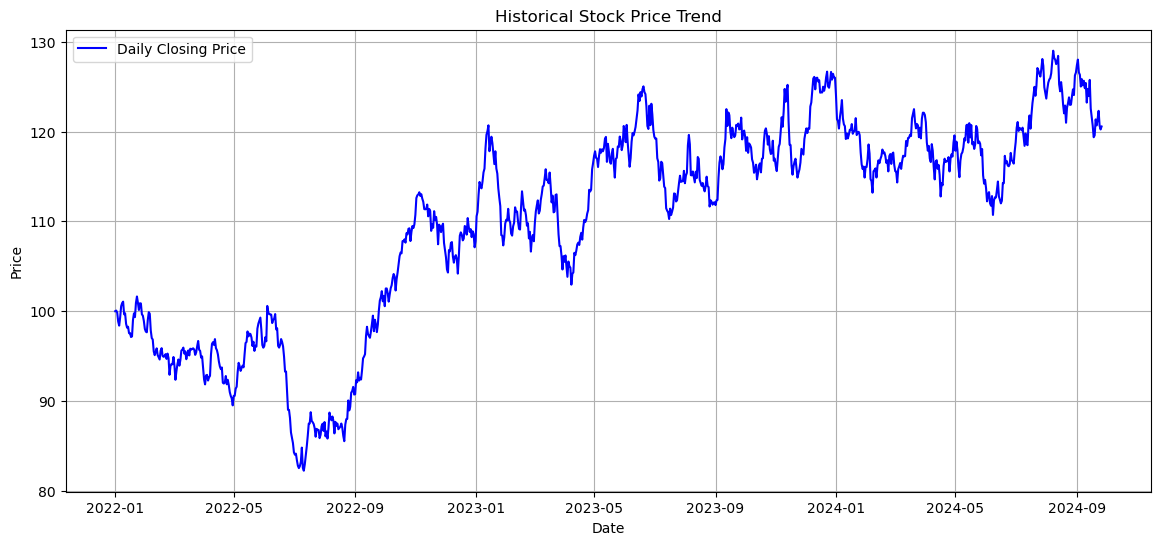

ADF Statistic: -1.048423568862262
p-value: 0.7351960015529135
ADF after differencing: -25.896920581946787 (p-value: 0.0)


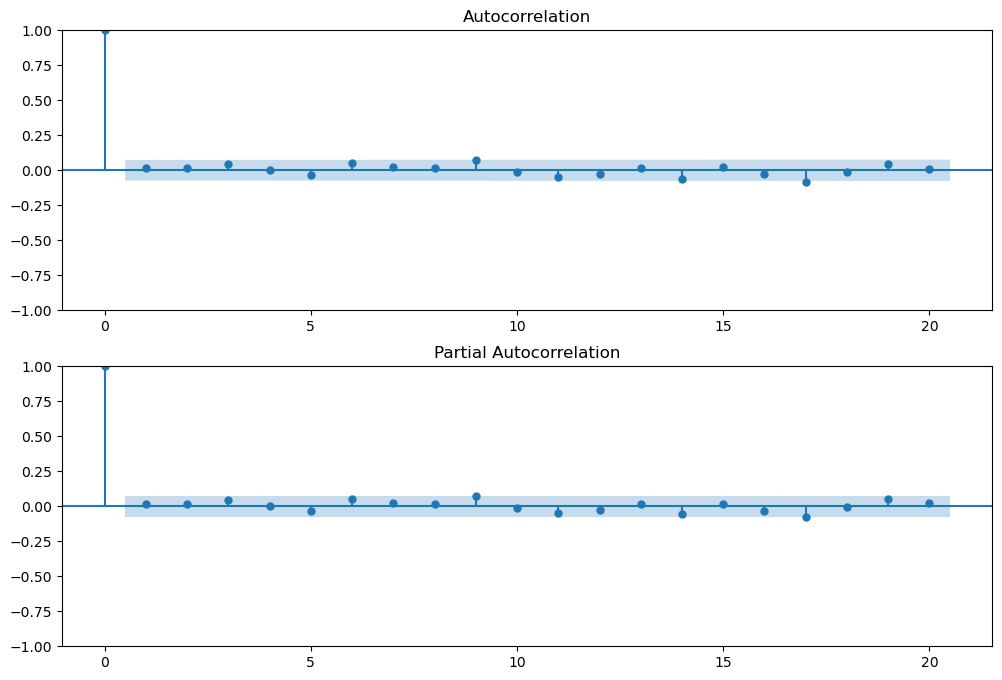

ARIMA Metrics - MAE: 3.43, MAPE: 2.86%, RMSE: 4.12
SARIMA Metrics - MAE: 5.36, MAPE: 4.55%, RMSE: 6.28
                                     SARIMAX Results                                     
Dep. Variable:                             Close   No. Observations:                  700
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -1050.841
Date:                           Sun, 25 May 2025   AIC                           2111.682
Time:                                   15:56:14   BIC                           2134.380
Sample:                               01-01-2022   HQIC                          2120.461
                                    - 12-01-2023                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.80

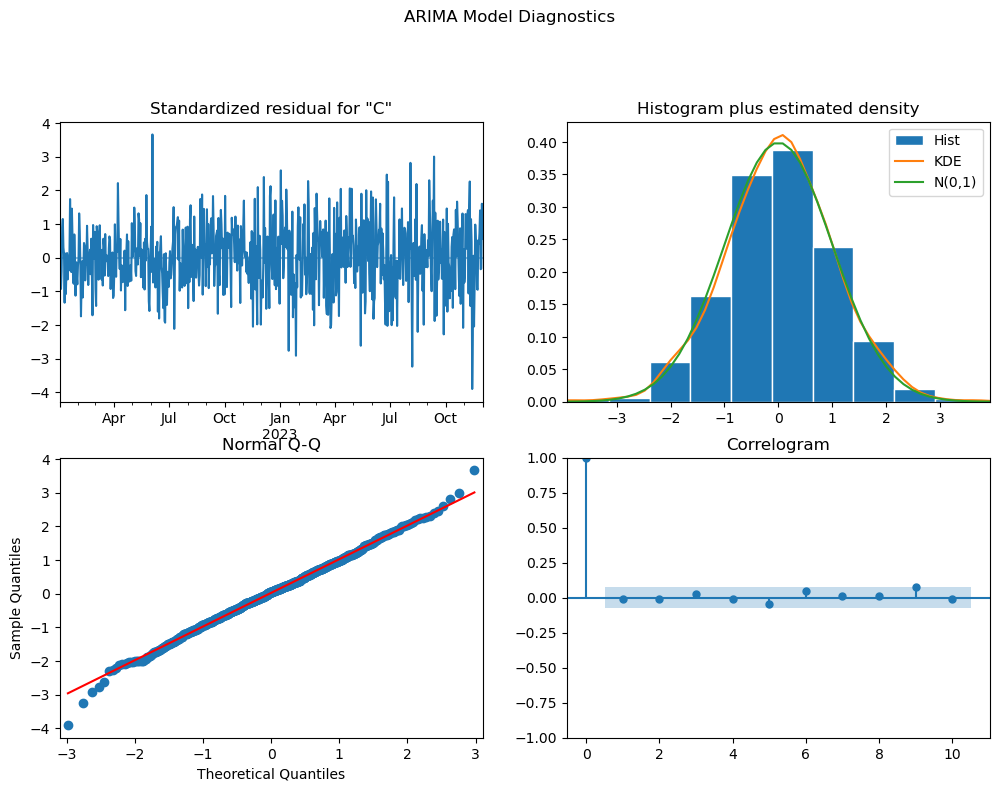

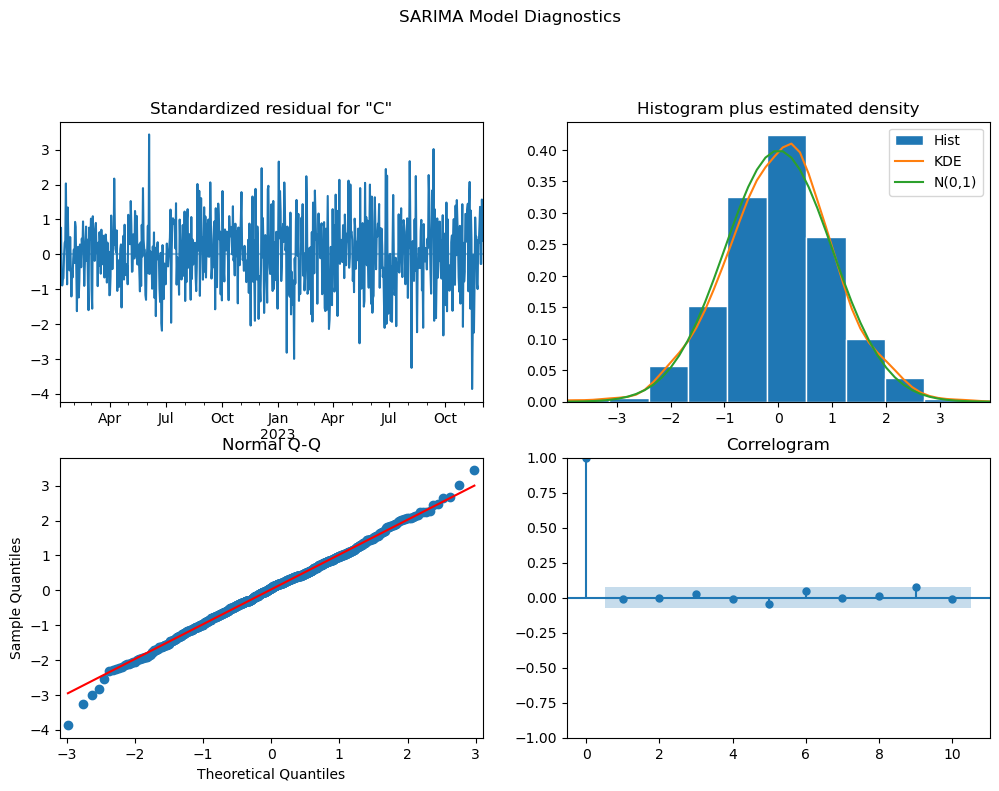

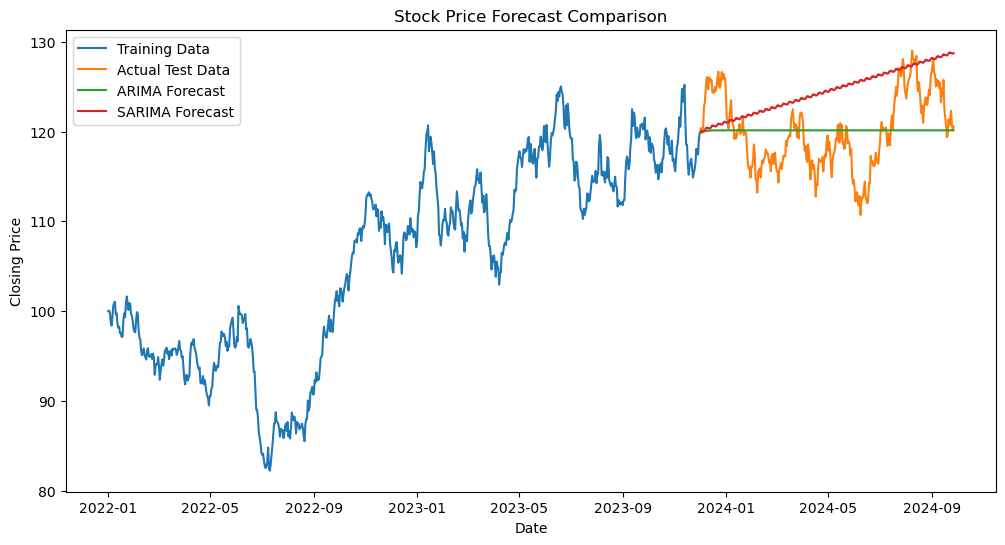

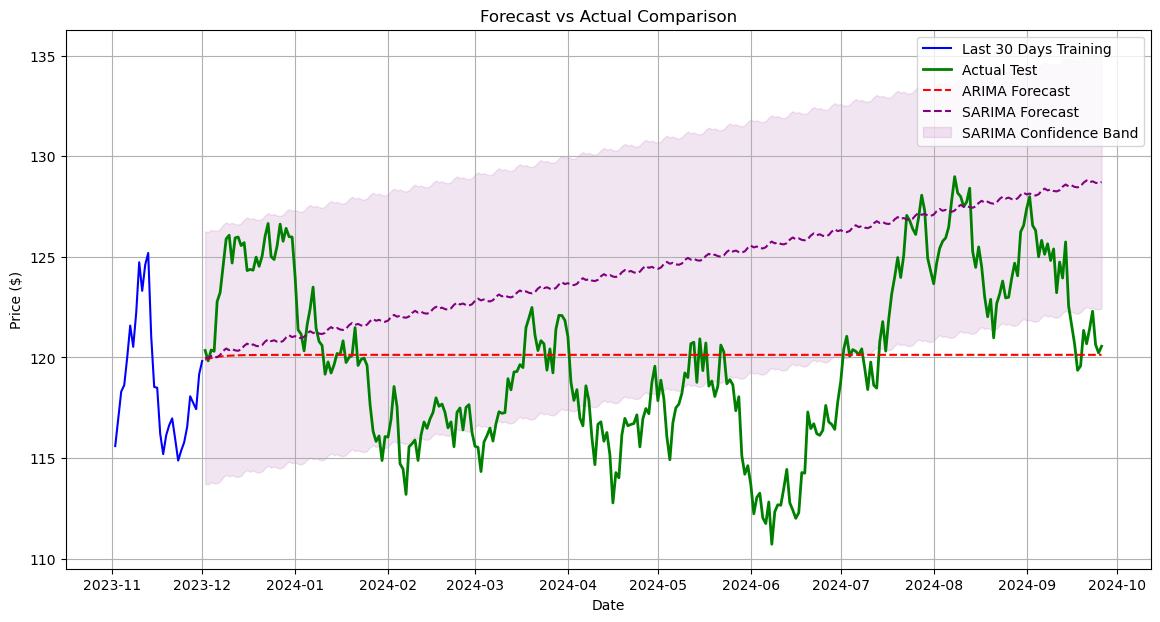

In [7]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load data
data = pd.read_csv("C:\\Users\\G A L A X Y\\Desktop\\statAss\\statAss\\Time Series Analysis Dataset\\synthetic_stock_data.csv")
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# Extract the 'Close' column
close_prices = data['Close']

# Plotting
plt.figure(figsize=(14, 6))
plt.plot(close_prices, label='Daily Closing Price', color='blue')
plt.title('Historical Stock Price Trend')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

# Split data (70% train, 30% test)
split_idx = int(len(close_prices) * 0.7)
train = close_prices[:split_idx]
test = close_prices[split_idx:]

# ADF Test
adf_result = adfuller(train)
print(f'ADF Statistic: {adf_result[0]}')
print(f'p-value: {adf_result[1]}')

# Differencing if needed
if adf_result[1] > 0.05:
    train_diff = train.diff().dropna()
    adf_diff = adfuller(train_diff)
    print(f'ADF after differencing: {adf_diff[0]} (p-value: {adf_diff[1]})')
else:
    train_diff = train  # no differencing needed

# Plot ACF and PACF
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(train_diff, ax=ax1, lags=20)
plot_pacf(train_diff, ax=ax2, lags=20)
plt.show()

# Fit ARIMA model
arima_model = ARIMA(train, order=(1, 1, 1))
arima_fit = arima_model.fit()

# Forecast
arima_forecast = arima_fit.forecast(steps=len(test))

# Fit SARIMA model (with weekly seasonality)
sarima_model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7))
sarima_fit = sarima_model.fit(disp=False)

# Forecast
sarima_forecast = sarima_fit.forecast(steps=len(test))

# Evaluation metrics
def calculate_metrics(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100  
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    return mae, mape, rmse

# Calculate metrics
arima_mae, arima_mape, arima_rmse = calculate_metrics(test, arima_forecast)
sarima_mae, sarima_mape, sarima_rmse = calculate_metrics(test, sarima_forecast)

# Print metrics
print(f"ARIMA Metrics - MAE: {arima_mae:.2f}, MAPE: {arima_mape:.2f}%, RMSE: {arima_rmse:.2f}")
print(f"SARIMA Metrics - MAE: {sarima_mae:.2f}, MAPE: {sarima_mape:.2f}%, RMSE: {sarima_rmse:.2f}")

# Summary
print(sarima_fit.summary())

# ARIMA diagnostics
arima_fit.plot_diagnostics(figsize=(12, 8))
plt.suptitle('ARIMA Model Diagnostics', y=1.02)
plt.show()

# SARIMA diagnostics
sarima_fit.plot_diagnostics(figsize=(12, 8))
plt.suptitle('SARIMA Model Diagnostics', y=1.02)
plt.show()

# Forecast comparison plot
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data')
plt.plot(test.index, test, label='Actual Test Data')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast')
plt.plot(test.index, sarima_forecast, label='SARIMA Forecast')
plt.title('Stock Price Forecast Comparison')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()
plt.show()

# Forecast vs actual with confidence band
plt.figure(figsize=(14, 7))
plt.plot(train.index[-30:], train[-30:], label='Last 30 Days Training', color='blue')
plt.plot(test.index, test, label='Actual Test', color='green', linewidth=2)
plt.plot(test.index, arima_forecast, label='ARIMA Forecast', color='red', linestyle='--')
plt.plot(test.index, sarima_forecast, label='SARIMA Forecast', color='purple', linestyle='--')
plt.fill_between(test.index, 
                 sarima_forecast - sarima_rmse, 
                 sarima_forecast + sarima_rmse,
                 color='purple', alpha=0.1, label='SARIMA Confidence Band')
plt.title('Forecast vs Actual Comparison')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.show()


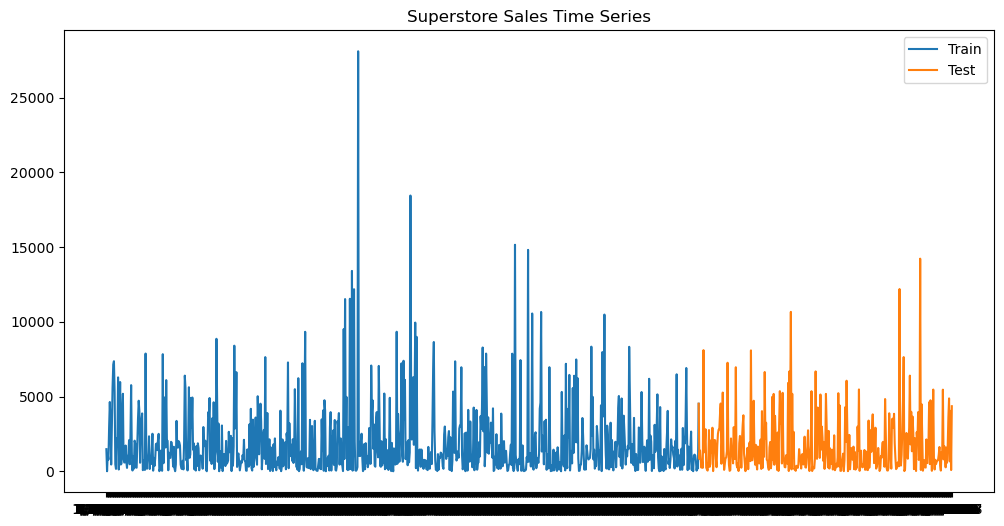

ADF Test for Original Series:
ADF Statistic: -6.457320586356377
p-value: 1.4723909628554064e-08
Critical Values:
   1%: -3.438130930004224
   5%: -2.864974613145216
   10%: -2.568598863756932

ADF Test for Differenced Series:
ADF Statistic: -11.424003009501364
p-value: 6.7649646214594494e-21
Critical Values:
   1%: -3.438130930004224
   5%: -2.864974613145216
   10%: -2.568598863756932


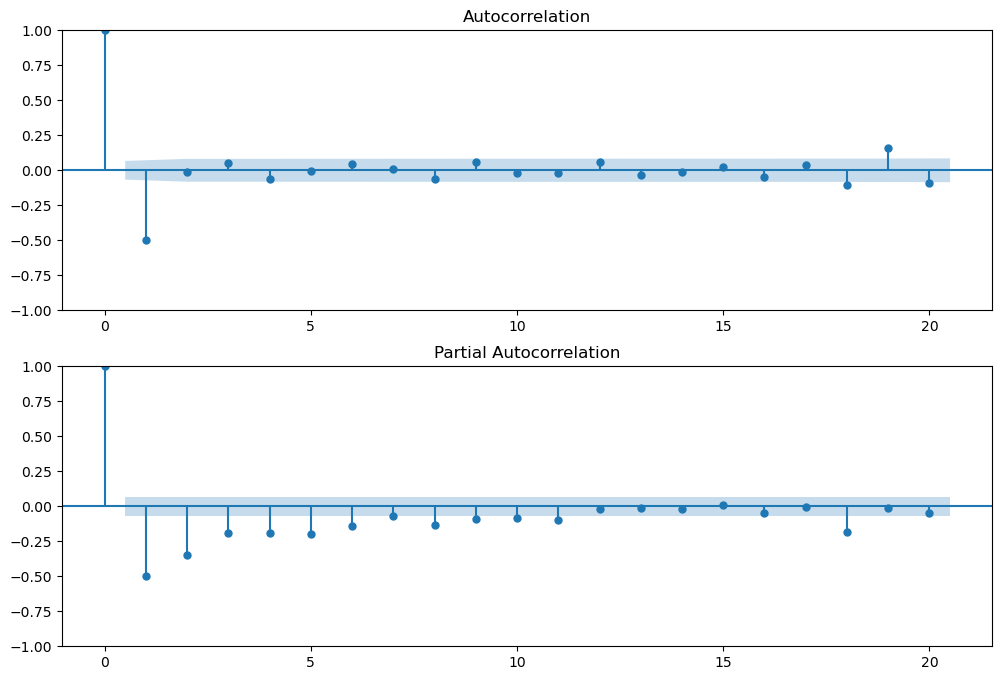

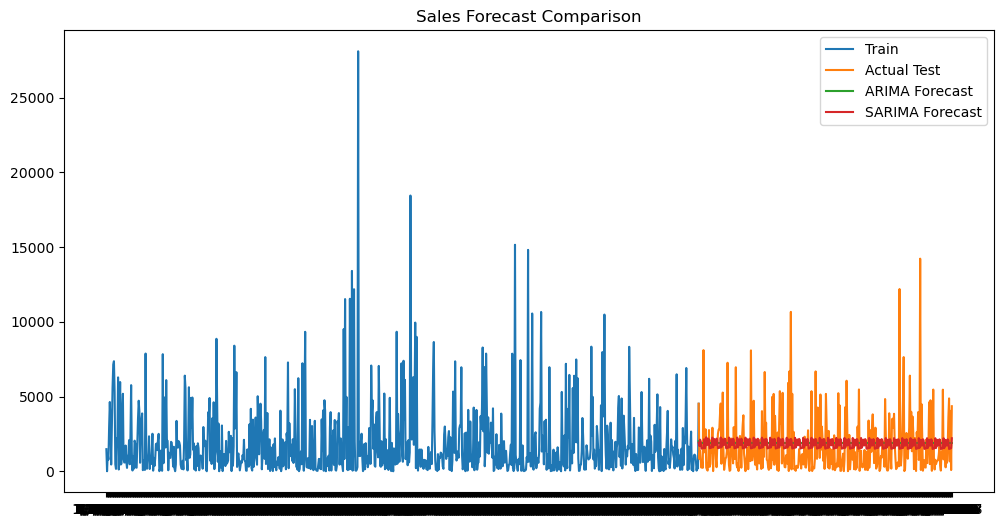

ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                  862
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -7937.426
Date:                Sun, 25 May 2025   AIC                          15880.852
Time:                        15:53:26   BIC                          15895.127
Sample:                             0   HQIC                         15886.317
                                - 862                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0431      0.041      1.042      0.298      -0.038       0.124
ma.L1         -1.0000      0.015    -67.230      0.000      -1.029      -0.971
sigma2      5.914e+06   2.52e-0

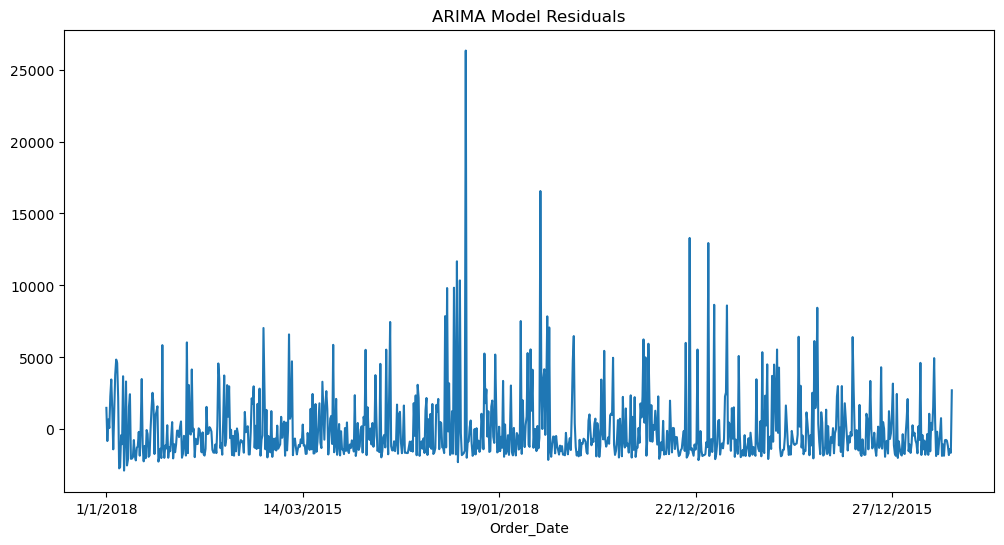

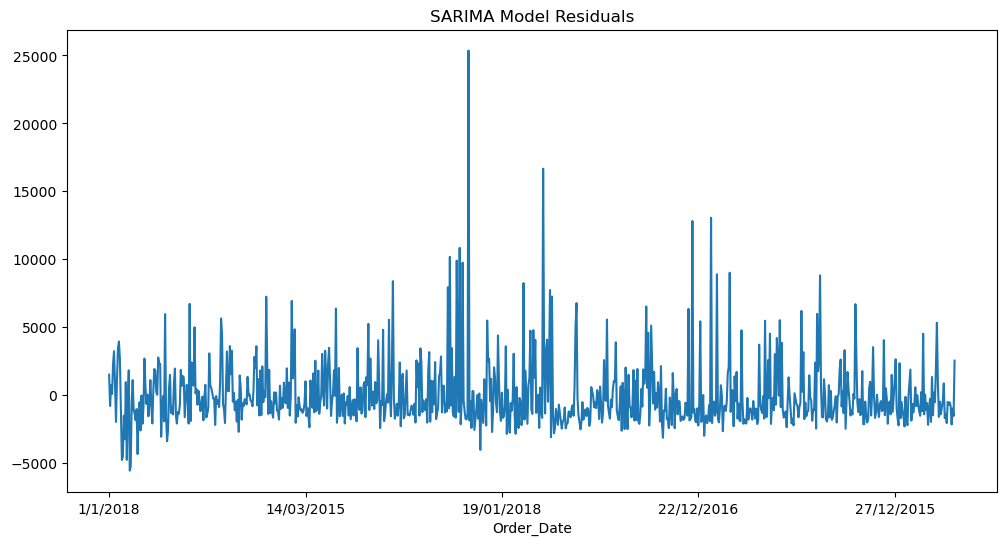

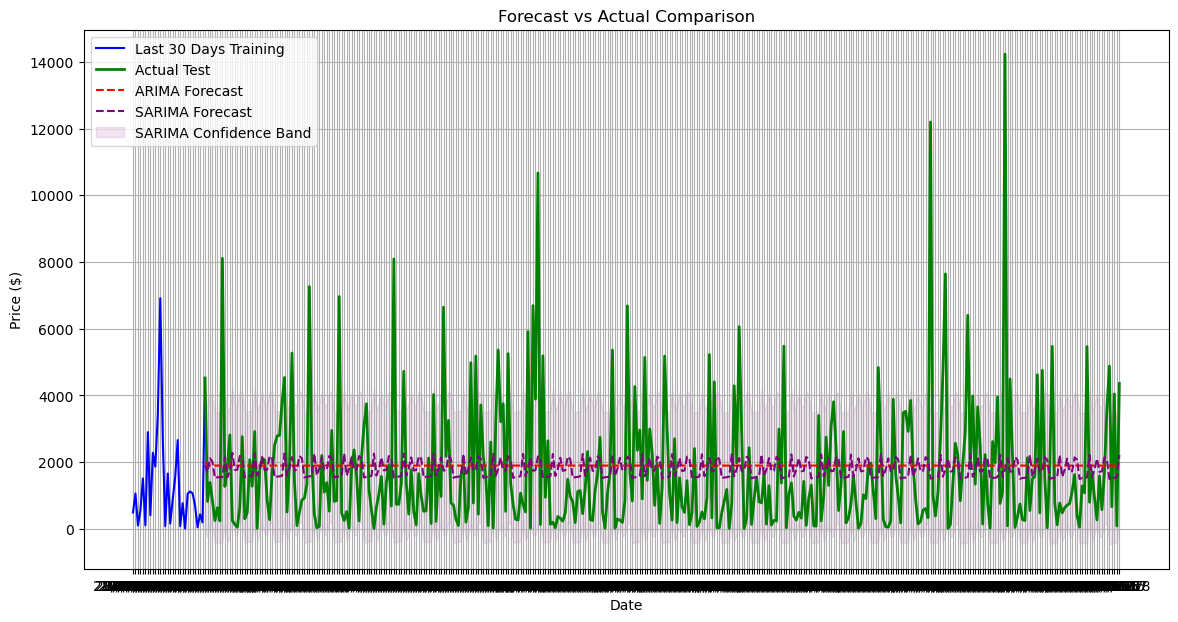

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Load and preprocess data
df = pd.read_csv("C:\\Users\\G A L A X Y\\Downloads\\superstore_final_dataset.csv", encoding='latin1')
df = df.sort_values('Order_Date')

# Aggregate sales by date
ts_data = df.groupby('Order_Date')['Sales'].sum().reset_index()
ts_data = ts_data.set_index('Order_Date')

# Split into train and test (70-30)
split_date = ts_data.index[int(len(ts_data)*0.7)]
train = ts_data.loc[:split_date]
test = ts_data.loc[split_date:]

# Plot the time series
plt.figure(figsize=(12,6))
plt.plot(train.index, train['Sales'], label='Train')
plt.plot(test.index, test['Sales'], label='Test')
plt.title('Superstore Sales Time Series')
plt.legend()
plt.show()

# Stationarity check
def adf_test(series):
    result = adfuller(series)
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'   {key}: {value}')

print("ADF Test for Original Series:")
adf_test(train['Sales'])

# Differencing if needed
train_diff = train.diff().dropna()
print("\nADF Test for Differenced Series:")
adf_test(train_diff['Sales'])

# ACF and PACF plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8))
plot_acf(train_diff, lags=20, ax=ax1)
plot_pacf(train_diff, lags=20, ax=ax2)
plt.show()

# Fit ARIMA model
arima_order = (1, 1, 1)  # Based on ACF/PACF
arima_model = ARIMA(train, order=arima_order)
arima_fit = arima_model.fit()

# Fit SARIMA model (assuming monthly seasonality)
sarima_order = (1, 1, 1)
sarima_seasonal_order = (1, 1, 1, 12)  # 12 for monthly
sarima_model = SARIMAX(train, order=sarima_order, seasonal_order=sarima_seasonal_order)
sarima_fit = sarima_model.fit()

# Generate forecasts
arima_forecast = arima_fit.forecast(steps=len(test))
sarima_forecast = sarima_fit.forecast(steps=len(test))

# Calculate error metrics
def calculate_metrics(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    mape = mean_absolute_percentage_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    return mae, mape, rmse

arima_mae, arima_mape, arima_rmse = calculate_metrics(test['Sales'], arima_forecast)
sarima_mae, sarima_mape, sarima_rmse = calculate_metrics(test['Sales'], sarima_forecast)

# Plot forecasts vs actual
plt.figure(figsize=(12,6))
plt.plot(train.index, train['Sales'], label='Train')
plt.plot(test.index, test['Sales'], label='Actual Test')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast')
plt.plot(test.index, sarima_forecast, label='SARIMA Forecast')
plt.title('Sales Forecast Comparison')
plt.legend()
plt.show()

# Model diagnostics
print("ARIMA Model Summary:")
print(arima_fit.summary())

print("\nSARIMA Model Summary:")
print(sarima_fit.summary())

# Error metrics comparison
metrics_df = pd.DataFrame({
    'Model': ['ARIMA', 'SARIMA'],
    'MAE': [arima_mae, sarima_mae],
    'MAPE': [arima_mape, sarima_mape],
    'RMSE': [arima_rmse, sarima_rmse]
})

print("\nModel Comparison Metrics:")
print(metrics_df)

# Plot residuals
arima_fit.resid.plot(figsize=(12,6))
plt.title('ARIMA Model Residuals')
plt.show()

sarima_fit.resid.plot(figsize=(12,6))
plt.title('SARIMA Model Residuals')
plt.show()

plt.figure(figsize=(14, 7))
plt.plot(train.index[-30:], train[-30:], label='Last 30 Days Training', color='blue')
plt.plot(test.index, test, label='Actual Test', color='green', linewidth=2)
plt.plot(test.index, arima_forecast, label='ARIMA Forecast', color='red', linestyle='--')
plt.plot(test.index, sarima_forecast, label='SARIMA Forecast', color='purple', linestyle='--')
plt.fill_between(test.index, 
                sarima_forecast - sarima_rmse, 
                sarima_forecast + sarima_rmse,
                color='purple', alpha=0.1, label='SARIMA Confidence Band')
plt.title('Forecast vs Actual Comparison')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.show()